# 3 · Correlations: $g^{(2)}$, Hanbury Brown–Twiss, and How We Make & Catch Photons

**Lecture · Tuesday July 28, 9:00–10:00 · Tim Thomay**

### Learning objectives

1. define $g^{(2)}(\tau)$ and state its $\tau=0$ value for coherent, thermal, and Fock states,
2. explain why the **HBT** beamsplitter geometry measures $g^{(2)}$ even with slow, dead-time-limited detectors,
3. compare single-photon **sources** and **detectors** by the figures of merit that actually matter.

*Key papers: [HanburyBrown1956], [Glauber1963], [Kimble1977]; reviews [Natarajan2012], [MeyerScott2020] — all in [`references.bib`](../references.bib).*

In [1]:
# Install packages if missing (needed on Google Colab; no-op in Codespaces).
import importlib.util, subprocess, sys
if importlib.util.find_spec("qutip") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", "qutip"])

import numpy as np
import matplotlib.pyplot as plt
import qutip

plt.rcParams.update({"figure.figsize": (6, 4), "font.size": 12,
                     "axes.grid": True, "grid.alpha": 0.3})
rng = np.random.default_rng(7)

## 3.1 · Warm-up quiz (2 minutes, shout the answers)

1. Attenuate a laser to $\bar n = 0.01$ per pulse. Mandel $Q$ of the output?
2. For thermal light, which $n$ has the highest probability — at *any* $\bar n$?
3. Yesterday's stretch exercise: a Fock state $|4\rangle$ after 75% loss — still non-classical?

## 3.2 · $P(n)$ says nothing about *time*

Yesterday's click-stream picture showed thermal photons arriving in clusters and single-emitter photons keeping their distance — but all of that structure is invisible in $P(n)$ measured over long windows. We need a quantity that asks:

> *given that I detected a photon at time $t$, how likely am I to detect another one at $t + \tau$?*

That is the **second-order (intensity) correlation function** [Glauber1963]:

$$g^{(2)}(\tau) = \frac{\langle \hat a^\dagger(t)\, \hat a^\dagger(t+\tau)\, \hat a(t+\tau)\, \hat a(t)\rangle}{\langle \hat a^\dagger \hat a\rangle^2}
\;\;\xrightarrow{\;\tau = 0,\ \text{single mode}\;}\;\;
g^{(2)}(0) = \frac{\langle \hat n(\hat n - 1)\rangle}{\langle \hat n\rangle^2}.$$

Note the **normal ordering** ($\hat a^\dagger$s to the left): the first detection *removes* a photon — $g^{(2)}$ automatically describes what the *remaining* field looks like. That $\hat n(\hat n-1)$ is the number of ordered photon *pairs*.

In [2]:
# g2(0) for our three families - three lines of QuTiP.
def g2_zero(state) -> float:
    """g2(0) = <n(n-1)> / <n>^2 for a single-mode state (ket or dm)."""
    n_op = qutip.num(state.shape[0])
    mean_n = qutip.expect(n_op, state)
    pairs = qutip.expect(n_op * (n_op - 1), state)   # <a+ a+ a a>
    return pairs / mean_n**2

N = 40
print("thermal nbar=2 :", f"{g2_zero(qutip.thermal_dm(N, 2.0)):.3f}   (theory: 2)")
print("coherent       :", f"{g2_zero(qutip.coherent(N, 2.0)):.3f}   (theory: 1)")
for n in [1, 2, 3, 4]:
    print(f"Fock |{n}>       : {g2_zero(qutip.fock(N, n)):.3f}   "
          f"(theory: 1 - 1/{n} = {1 - 1/n:.3f})")

thermal nbar=2 : 2.000   (theory: 2)
coherent       : 1.000   (theory: 1)
Fock |1>       : 0.000   (theory: 1 - 1/1 = 0.000)
Fock |2>       : 0.500   (theory: 1 - 1/2 = 0.500)
Fock |3>       : 0.667   (theory: 1 - 1/3 = 0.667)
Fock |4>       : 0.750   (theory: 1 - 1/4 = 0.750)


$$g^{(2)}(0) = 2 \;\text{(thermal)}, \qquad 1 \;\text{(coherent)}, \qquad 1 - \tfrac1n \;\text{(Fock)}.$$

Two boundaries to memorize:

* **Classical light cannot go below 1.** For any classical intensity distribution, $g^{(2)}(0) = \langle I^2\rangle / \langle I\rangle^2 \ge 1$ (Cauchy–Schwarz). **$g^{(2)}(0) < 1$ = antibunching = non-classical**, full stop.
* **$g^{(2)}(0) < 1/2$** is the practical certificate for a *single*-photon source: any state with a two-photon component larger than that of $|1\rangle$-dominated light fails it (note $g^{(2)}(0) = 1/2$ for $|2\rangle$).

And away from $\tau = 0$ every stationary source decorrelates, $g^{(2)}(\infty) = 1$:

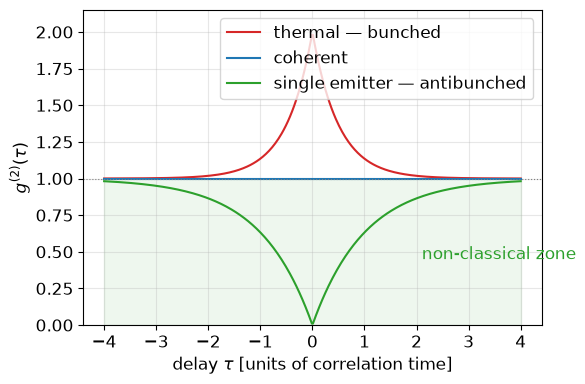

In [3]:
# The three canonical g2(tau) shapes (analytic single-mode models).
tau = np.linspace(-4, 4, 400)          # in units of the correlation time

g2_thermal = 1 + np.exp(-2 * np.abs(tau))     # chaotic light (Lorentzian spectrum)
g2_coherent = np.ones_like(tau)
g2_emitter = 1 - np.exp(-np.abs(tau))         # two-level emitter, low pumping

fig, ax = plt.subplots()
ax.plot(tau, g2_thermal, color="tab:red", label="thermal — bunched")
ax.plot(tau, g2_coherent, color="tab:blue", label="coherent")
ax.plot(tau, g2_emitter, color="tab:green", label="single emitter — antibunched")
ax.axhline(1, color="gray", lw=0.8, ls=":")
ax.fill_between(tau, 0, 1, alpha=0.08, color="tab:green")
ax.annotate("non-classical zone", (2.1, 0.45), color="tab:green")
ax.set_xlabel(r"delay $\tau$ [units of correlation time]")
ax.set_ylabel(r"$g^{(2)}(\tau)$")
ax.set_ylim(0, 2.15)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## 3.3 · Hanbury Brown–Twiss: how to actually measure $g^{(2)}$

**The problem.** $g^{(2)}(\tau)$ near $\tau = 0$ requires resolving photon pairs a few ns apart. But a single-photon detector goes *blind* for 10–100 ns after each click (**dead time**) — one detector can never see both members of a close pair.

**The trick** [HanburyBrown1956]: split the beam on a 50:50 beamsplitter and put one detector in each output. Each photon chooses a side at random; close pairs end up on *different* detectors half the time, and those detectors don't share dead time. Record **coincidences vs. delay** $\tau$ between the two channels:

```
                   ┌── D1 ──┐   start
 source ──── BS ───┤        ├──▶ correlator ──▶ histogram ∝ g⁽²⁾(τ)
              │    └── D2 ──┘   stop
              ▼
            (50:50)
```

The normalized coincidence histogram **is** $g^{(2)}(\tau)$. Crucially, the beamsplitter does *not* change the statistics: splitting is binomial thinning (yesterday's stretch exercise!), and $g^{(2)}$ is invariant under loss — one of the reasons it is a more robust witness than Mandel $Q$.

Historical footnote: Hanbury Brown and Twiss built this to measure *stellar diameters* via intensity correlations — the bunching of thermal starlight. The observation that a laser gives a *flat* $g^{(2)}$ while a lamp shows *bunching* was a founding result of quantum optics, and the antibunching of a single atom [Kimble1977] was its first genuinely quantum effect.

**Higher orders:** with more beamsplitters and detectors you measure $g^{(3)}, g^{(4)}, \dots$ —

$$g^{(k)}(0) = \frac{\langle \hat n (\hat n -1)\cdots(\hat n - k + 1)\rangle}{\langle \hat n\rangle^k},$$

which distinguish states that $g^{(2)}$ confuses (e.g. is your $g^{(2)}(0) = 0.5$ a noisy single-photon source or a clean $|2\rangle$? $g^{(3)}$ knows: $0$ for $|2\rangle$).

## 3.4 · Making quantum light

| source | mechanism | statistics | the catch |
|---|---|---|---|
| **attenuated laser** | loss on coherent state | Poisson, $g^{(2)}=1$ | *never* becomes single-photon |
| **SPDC / four-wave mixing** | $\chi^{(2)}/\chi^{(3)}$: pump photon → signal + idler **pair** | each arm alone: *thermal*! pairs: perfectly correlated | probabilistic; multi-pair events at high pump |
| **heralded SPDC** | detect idler ⇒ "herald" signal | $\to$ Fock $\lvert 1\rangle$ (or $\lvert 2\rangle$, ... with PNR herald) | rate × purity trade-off (**Wednesday's lab!**) |
| **single quantum emitter** (QD, NV, molecule, atom) | one excitation ⇒ one photon per lifetime | antibunched, $g^{(2)}(0)\to 0$ | collection efficiency; indistinguishability |

Two of these rows are the plot of Wednesday's session: SPDC + heralding is **Lecture 6**, and the pair correlations behind it power the HOM interference of **Lecture 5**. Source quality is quantified by brightness, purity $1 - g^{(2)}(0)$, heralding efficiency, and photon indistinguishability — see [MeyerScott2020] for the full scorecard.

## 3.5 · Catching photons

| detector | principle | efficiency | dead time | jitter | photon-number resolving? |
|---|---|---|---|---|---|
| **SPAD** (Si/InGaAs avalanche) | avalanche breakdown | 10–70 % | 20–100 ns | 50–500 ps | no (click/no-click) |
| **SNSPD** (superconducting nanowire) | hotspot breaks superconductivity | up to 98 % | ~10–50 ns | < 15 ps | mostly no* |
| **TES** (transition-edge sensor) | calorimeter on the superconducting transition | ~95 % | µs (slow!) | ~100 ns | **yes**, true energy-resolving |

\* multiplexing helps: split the beam over $M$ click detectors (spatially or in time) and *count the clicks* — a quasi-PNR detector, good until two photons hit the same element. SNSPD arrays with tens of pixels are today's workhorse for photonic quantum computing; reviews: [Natarajan2012].

**Every real detector adds:** finite efficiency $\eta$ (binomial thinning — you know what that does), **dark counts** (uncorrelated Poisson background → pushes measured $g^{(2)}(0)$ of a quantum source *up* toward 1), and **jitter** (smears the histogram in $\tau$). You will meet all three in the data of the next session.

## 3.6 · Check your understanding

1. Why does a 50:50 beamsplitter *not* alter $g^{(2)}$ of the transmitted light, while it *does* alter $Q$? What does this tell you about which witness to use in a lossy lab?
2. An SPDC source produces two-mode states with perfect photon-number correlation between signal and idler. If you ignore the idler completely, why is the signal arm *thermal*?
3. Your measured antibunching dip goes to $g^{(2)}(0) = 0.2$ instead of 0. List three experimental imperfections that could be responsible, and one measurement you could do to identify which it is.
4. Design sketch: how would you measure $g^{(3)}(0)$ with click detectors only?

**Next (10:30, same room):** three mystery time-tag datasets — one thermal, one coherent, one single emitter. You get the raw detector output; you tell me which is which: [`04_HandsOn_g2_HBT`](04_HandsOn_g2_HBT.ipynb).